# Spatial Transcriptomics Analysis

source: https://lmweber.org/OSTA/ (original in R)

## 9. Quality Control

In [120]:
import numpy as np
import scanpy as sc
import seaborn as sns
from scipy.stats import median_abs_deviation
from matplotlib import pyplot as plt

sc.settings.verbosity = 0
sc.settings.set_figure_params(
    dpi=80,
    facecolor="white",
    frameon=False,
)

## 9.1 Preamble

Low-quality spots can be identified according to several characteristics, including:
- library size (i.e. total unique molecular identifier (UMI) counts per spot)
- number of expressed features (i.e. number of genes with non-zero UMI counts per spot)
- proportion of reads mapping to mitochondrial genes (a high proportion indicates cell damage)
- number of cells per spot (unusually high values can indicate problems due to unsuccessful cell segmentation as a computational step, or tissue damage) 

## 9.2 Calculate QC metrics

First, we subset the object to keep only spots covered by the tissue section. The remaining spots are background spots, which we are not interested in as they will contain almost entirely mitochondrial genes and transcripts from cellular debris.

The QC metrics from scater can be calculated and added to the SpatialExperiment object’s column data using the addPerCellQC function. The sum column contains the total number of unique molecular identifiers (UMIs) for each spot, the detected column contains the number of unique genes detected per spot, and subsets_mito_percent contains the percentage (or proportion) of transcripts mapping to mitochondrial genes per spot.


sum                  --> total number of UMIs per spot                          --> total_counts

detected             --> number of unique genes per spot                        --> n_genes_by_counts

subsets_mito_percent --> percentage of transcripts mapping to mt genes per spot --> pct_counts_mt

In [121]:
import os

adata = sc.read_h5ad(os.path.join("..", "datasets", "GSM6592049_M2.h5ad"))
adata.var_names_make_unique()
adata

AnnData object with n_obs × n_vars = 4992 × 36386
    obs: 'in_tissue', 'array_row', 'array_col', 'suspension_type', 'assay_ontology_term_id', 'Sample_ID', 'organism_ontology_term_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_type', 'tissue_ontology_term_id', 'pathologist_annotation', 'B-cells', 'CAFs', 'Cancer Epithelial', 'Endothelial', 'Myeloid', 'Normal Epithelial', 'PVL', 'T-cells', 'stereoscope_annotation', 'cell_type_ontology_term_id', 'is_primary_data', 'treatment', 'donor_id', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_types', 'genome', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'ensemble_id'
    uns: 'citation', 'schema_reference', 'schema_version', 'spatial', 'title'
    obsm: 'spatial'

In [123]:
# subset to keep only spots over tissue
print(adata.obs.in_tissue.value_counts())

adata = adata[adata.obs["in_tissue"] == True, :]
adata

in_tissue
0    3144
1    1848
Name: count, dtype: int64


View of AnnData object with n_obs × n_vars = 1848 × 36386
    obs: 'in_tissue', 'array_row', 'array_col', 'suspension_type', 'assay_ontology_term_id', 'Sample_ID', 'organism_ontology_term_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_type', 'tissue_ontology_term_id', 'pathologist_annotation', 'B-cells', 'CAFs', 'Cancer Epithelial', 'Endothelial', 'Myeloid', 'Normal Epithelial', 'PVL', 'T-cells', 'stereoscope_annotation', 'cell_type_ontology_term_id', 'is_primary_data', 'treatment', 'donor_id', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_types', 'genome', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'ensemble_id'
    uns: 'citation', 'schema_reference', 'schema_version', 'spatial', 'title'
    obsm: 'spatial'

In [102]:
# identify mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")
adata.var.mt.value_counts()

C:\Users\rebec\AppData\Local\Temp\ipykernel_8292\3116460902.py:2: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["mt"] = adata.var_names.str.startswith("MT-")


mt
False    36373
True        13
Name: count, dtype: int64

In [103]:
adata.var_names[adata.var["mt"]]

Index(['MT-ATP6', 'MT-ATP8', 'MT-CO1', 'MT-CO2', 'MT-CO3', 'MT-CYB', 'MT-ND1',
       'MT-ND2', 'MT-ND3', 'MT-ND4', 'MT-ND4L', 'MT-ND5', 'MT-ND6'],
      dtype='object')

In [104]:
# calculate per-spot QC metrics
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True, log1p=True)
adata

AnnData object with n_obs × n_vars = 1848 × 36386
    obs: 'in_tissue', 'array_row', 'array_col', 'suspension_type', 'assay_ontology_term_id', 'Sample_ID', 'organism_ontology_term_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_type', 'tissue_ontology_term_id', 'pathologist_annotation', 'B-cells', 'CAFs', 'Cancer Epithelial', 'Endothelial', 'Myeloid', 'Normal Epithelial', 'PVL', 'T-cells', 'stereoscope_annotation', 'cell_type_ontology_term_id', 'is_primary_data', 'treatment', 'donor_id', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var

In [ ]:
# Plot histogram of total_counts, colored by 'in_tissue' (True/False)
p1 = sns.displot(
    data=adata.obs,
    x="total_counts",
    hue="in_tissue",     # Color by this boolean column
    bins=100,
    kde=False,
    multiple="stack"     # Use 'stack' or 'layer' depending on preference
)

plt.show()

## 9.3 Global outlier detection

The simplest option for identifying potential low-quality spots is to apply fixed thresholds to each QC metric across the entire sample, and remove any spots that do not meet the thresholds for one or more metrics.

For example, we might consider spots to be of low-qualty if they have library sizes below 600 UMI or mitochondrial propotion above 30%. These cutoffs are somewhat arbitrary and often require knowledge of the tissue type and dataset at hand. In particular, exploratory visualizations can be used to help select appropriate thresholds, which may differ depending on the dataset.

Here, we use visualizations to select thresholds for several QC metrics in our human DLPFC dataset: (i) library size, (ii) number of expressed genes, (iii) proportion of mitochondrial reads, and (iv) number of cells per spot.

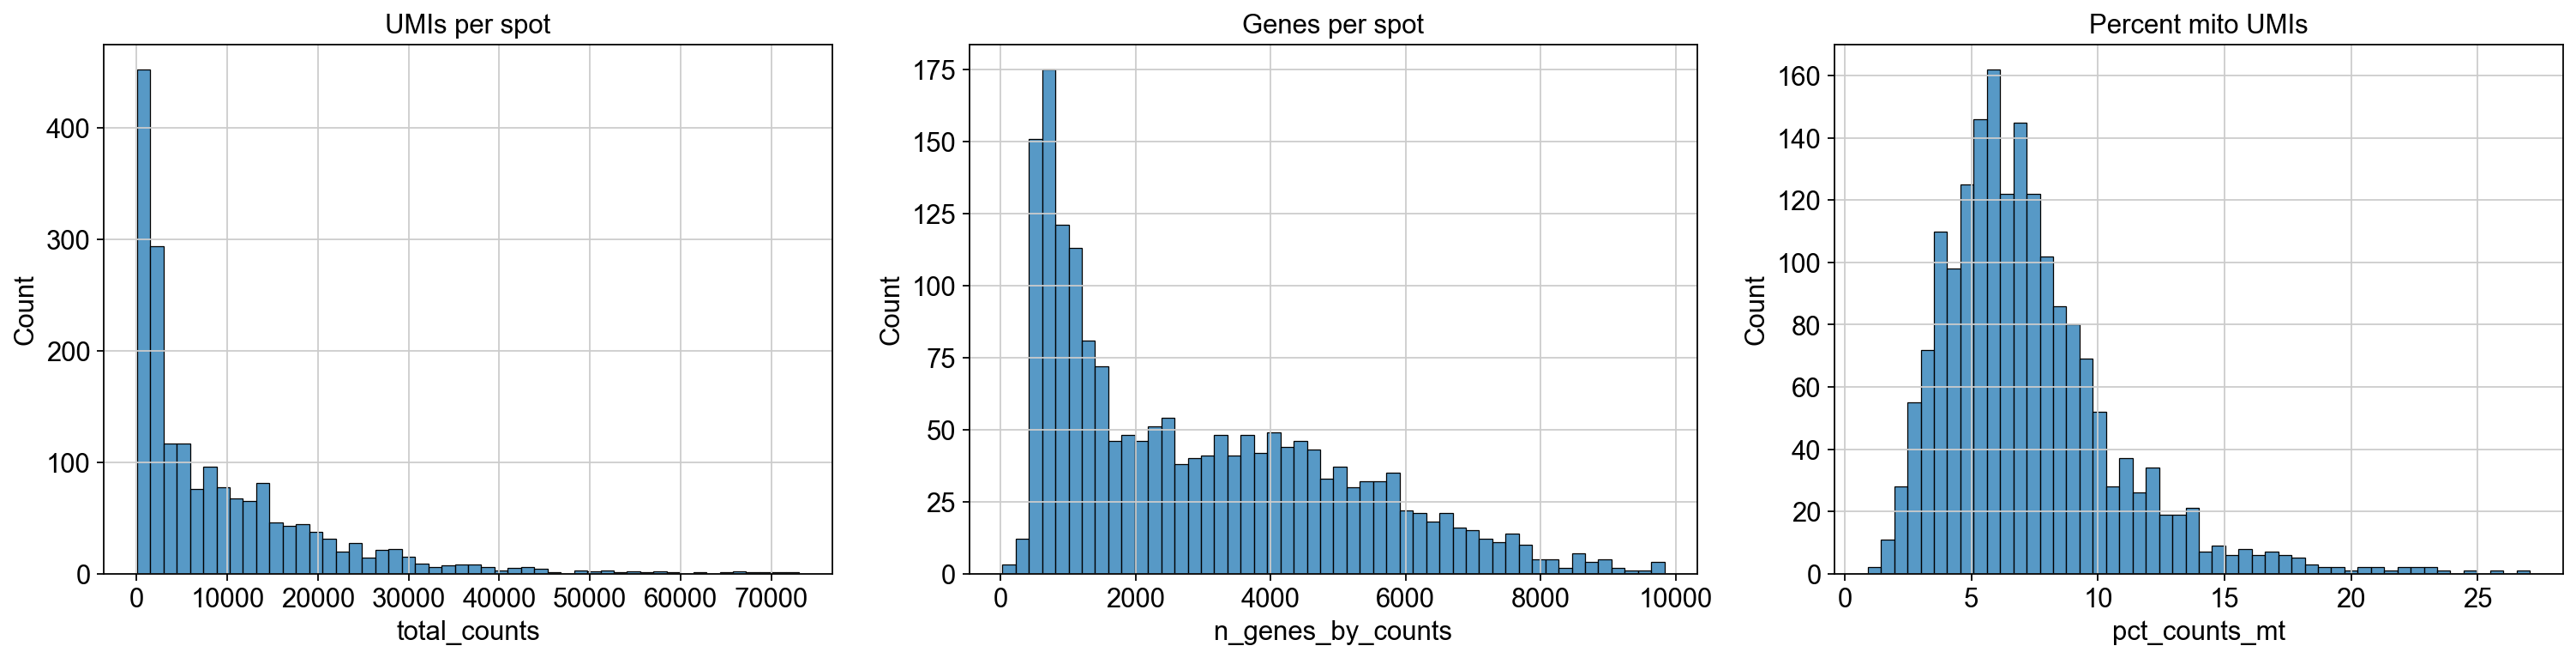

In [105]:
#  plot the three QC covariates n_genes_by_counts, total_counts and pct_counts_mt per sample

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

sns.histplot(adata.obs["total_counts"], bins=50, kde=False, ax=axes[0])
axes[0].set_title("UMIs per spot")

sns.histplot(adata.obs["n_genes_by_counts"], bins=50, kde=False, ax=axes[1])
axes[1].set_title("Genes per spot")

sns.histplot(adata.obs["pct_counts_mt"], bins=50, kde=False, ax=axes[2])
axes[2].set_title("Percent mito UMIs")

plt.tight_layout()
plt.show()

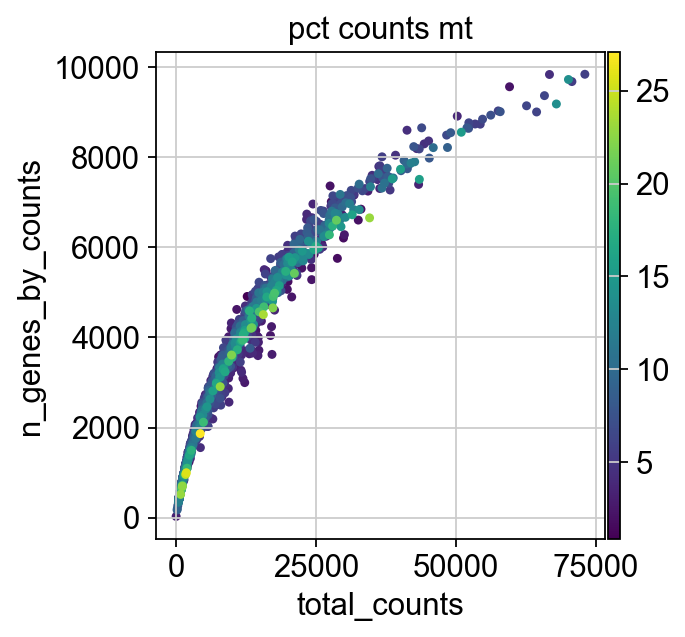

In [106]:
p3 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [107]:
# select QC threshold for library size
adata.obs["qc_lib_size"] = adata.obs["total_counts"] < 500
adata.obs.qc_lib_size.value_counts()

qc_lib_size
False    1838
True       10
Name: count, dtype: int64

In [108]:
# select QC threshold for detected features
adata.obs["qc_detected"] = adata.obs["n_genes_by_counts"] < 400
adata.obs.qc_detected.value_counts()

qc_detected
False    1838
True       10
Name: count, dtype: int64

In [109]:
# select QC threshold for mito proportion
adata.obs["qc_mito_prop"] = adata.obs["pct_counts_mt"] > 20
adata.obs.qc_mito_prop.value_counts()

qc_mito_prop
False    1833
True       15
Name: count, dtype: int64

C:\Users\rebec\AppData\Local\Temp\ipykernel_8292\3836548952.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
C:\Users\rebec\AppData\Local\Temp\ipykernel_8292\3836548952.py:14: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
C:\Users\rebec\AppData\Local\Temp\ipykernel_8292\3836548952.py:25: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


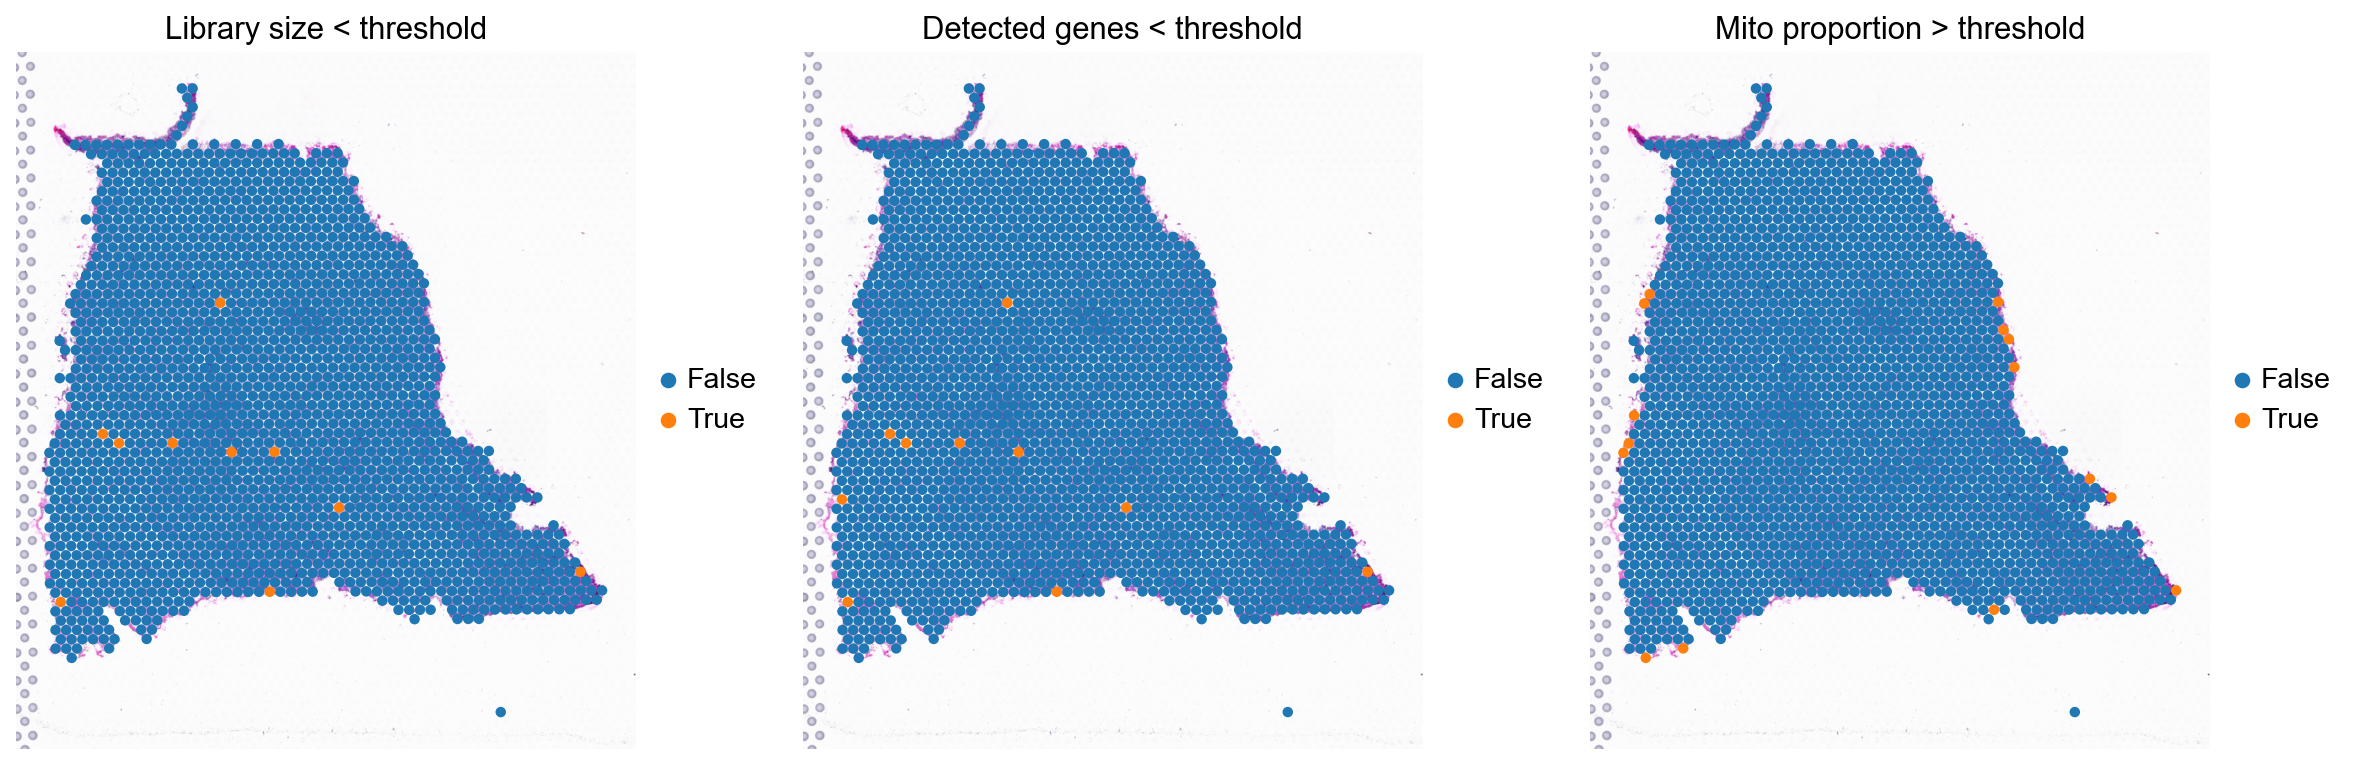

In [111]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sc.pl.spatial(
    adata,
    color="qc_lib_size",
    library_id="GSM6592049_M2",
    cmap="viridis",  # or any colormap
    size=1.5,
    title="Library size < threshold",
    ax=axes[0],
    show=False
)

sc.pl.spatial(
    adata,
    color="qc_detected",
    library_id="GSM6592049_M2",
    cmap="viridis",  # or any colormap
    size=1.5,
    title="Detected genes < threshold",
    ax=axes[1],
    show=False
)

sc.pl.spatial(
    adata,
    color="qc_mito_prop",
    library_id="GSM6592049_M2",
    cmap="viridis",  # or any colormap
    size=1.5,
    title="Mito proportion > threshold",
    ax=axes[2],
    show=False
)

plt.tight_layout()
plt.show()

## 9.4 Local outlier detection

One of the key assumptions of global outlier detection in single cell and spatial transcriptomics is that the QC metrics are independent of natural biology. Otherwise, cell or spots with naturally low library size or higher mitochondrial ratio will be more likely to be removed as outliers.

In [112]:
def local_outliers(adata, metric, direction):
    # Log-transform the total counts
    log_total_counts = adata.obs[metric]

    # Define outliers: e.g., 1.5 IQR below Q1 (standard Tukey method)
    Q1 = np.percentile(log_total_counts, 25)
    Q3 = np.percentile(log_total_counts, 75)
    IQR = Q3 - Q1

    if direction == "lower":
        lower_bound = Q1 - 1.5 * IQR
        return log_total_counts < lower_bound
    elif direction == "higher":
        upper_bound = Q3 + 1.5 * IQR
        return log_total_counts > upper_bound

# library size
adata.obs["sum_outliers"] = local_outliers(adata, "log1p_total_counts", "lower")

# unique genes
adata.obs["detected_outliers"] = local_outliers(adata, "log1p_n_genes_by_counts", "lower")

# mitochondrial percent
adata.obs["mt_pct_outliers"] = local_outliers(adata, "pct_counts_mt", "higher")

C:\Users\rebec\AppData\Local\Temp\ipykernel_8292\2246096891.py:7: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
C:\Users\rebec\AppData\Local\Temp\ipykernel_8292\2246096891.py:18: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
C:\Users\rebec\AppData\Local\Temp\ipykernel_8292\2246096891.py:30: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
C:\Users\rebec\AppData\Local\Temp\ipykernel_8292\2246096891.py:41: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
C:\Users\rebec\AppData\Local\Temp\ipykernel_8292\2246096891.py:52: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
C:\Users\rebec\AppData\Local\Temp\ipykernel_8292\2246096891.py:63: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


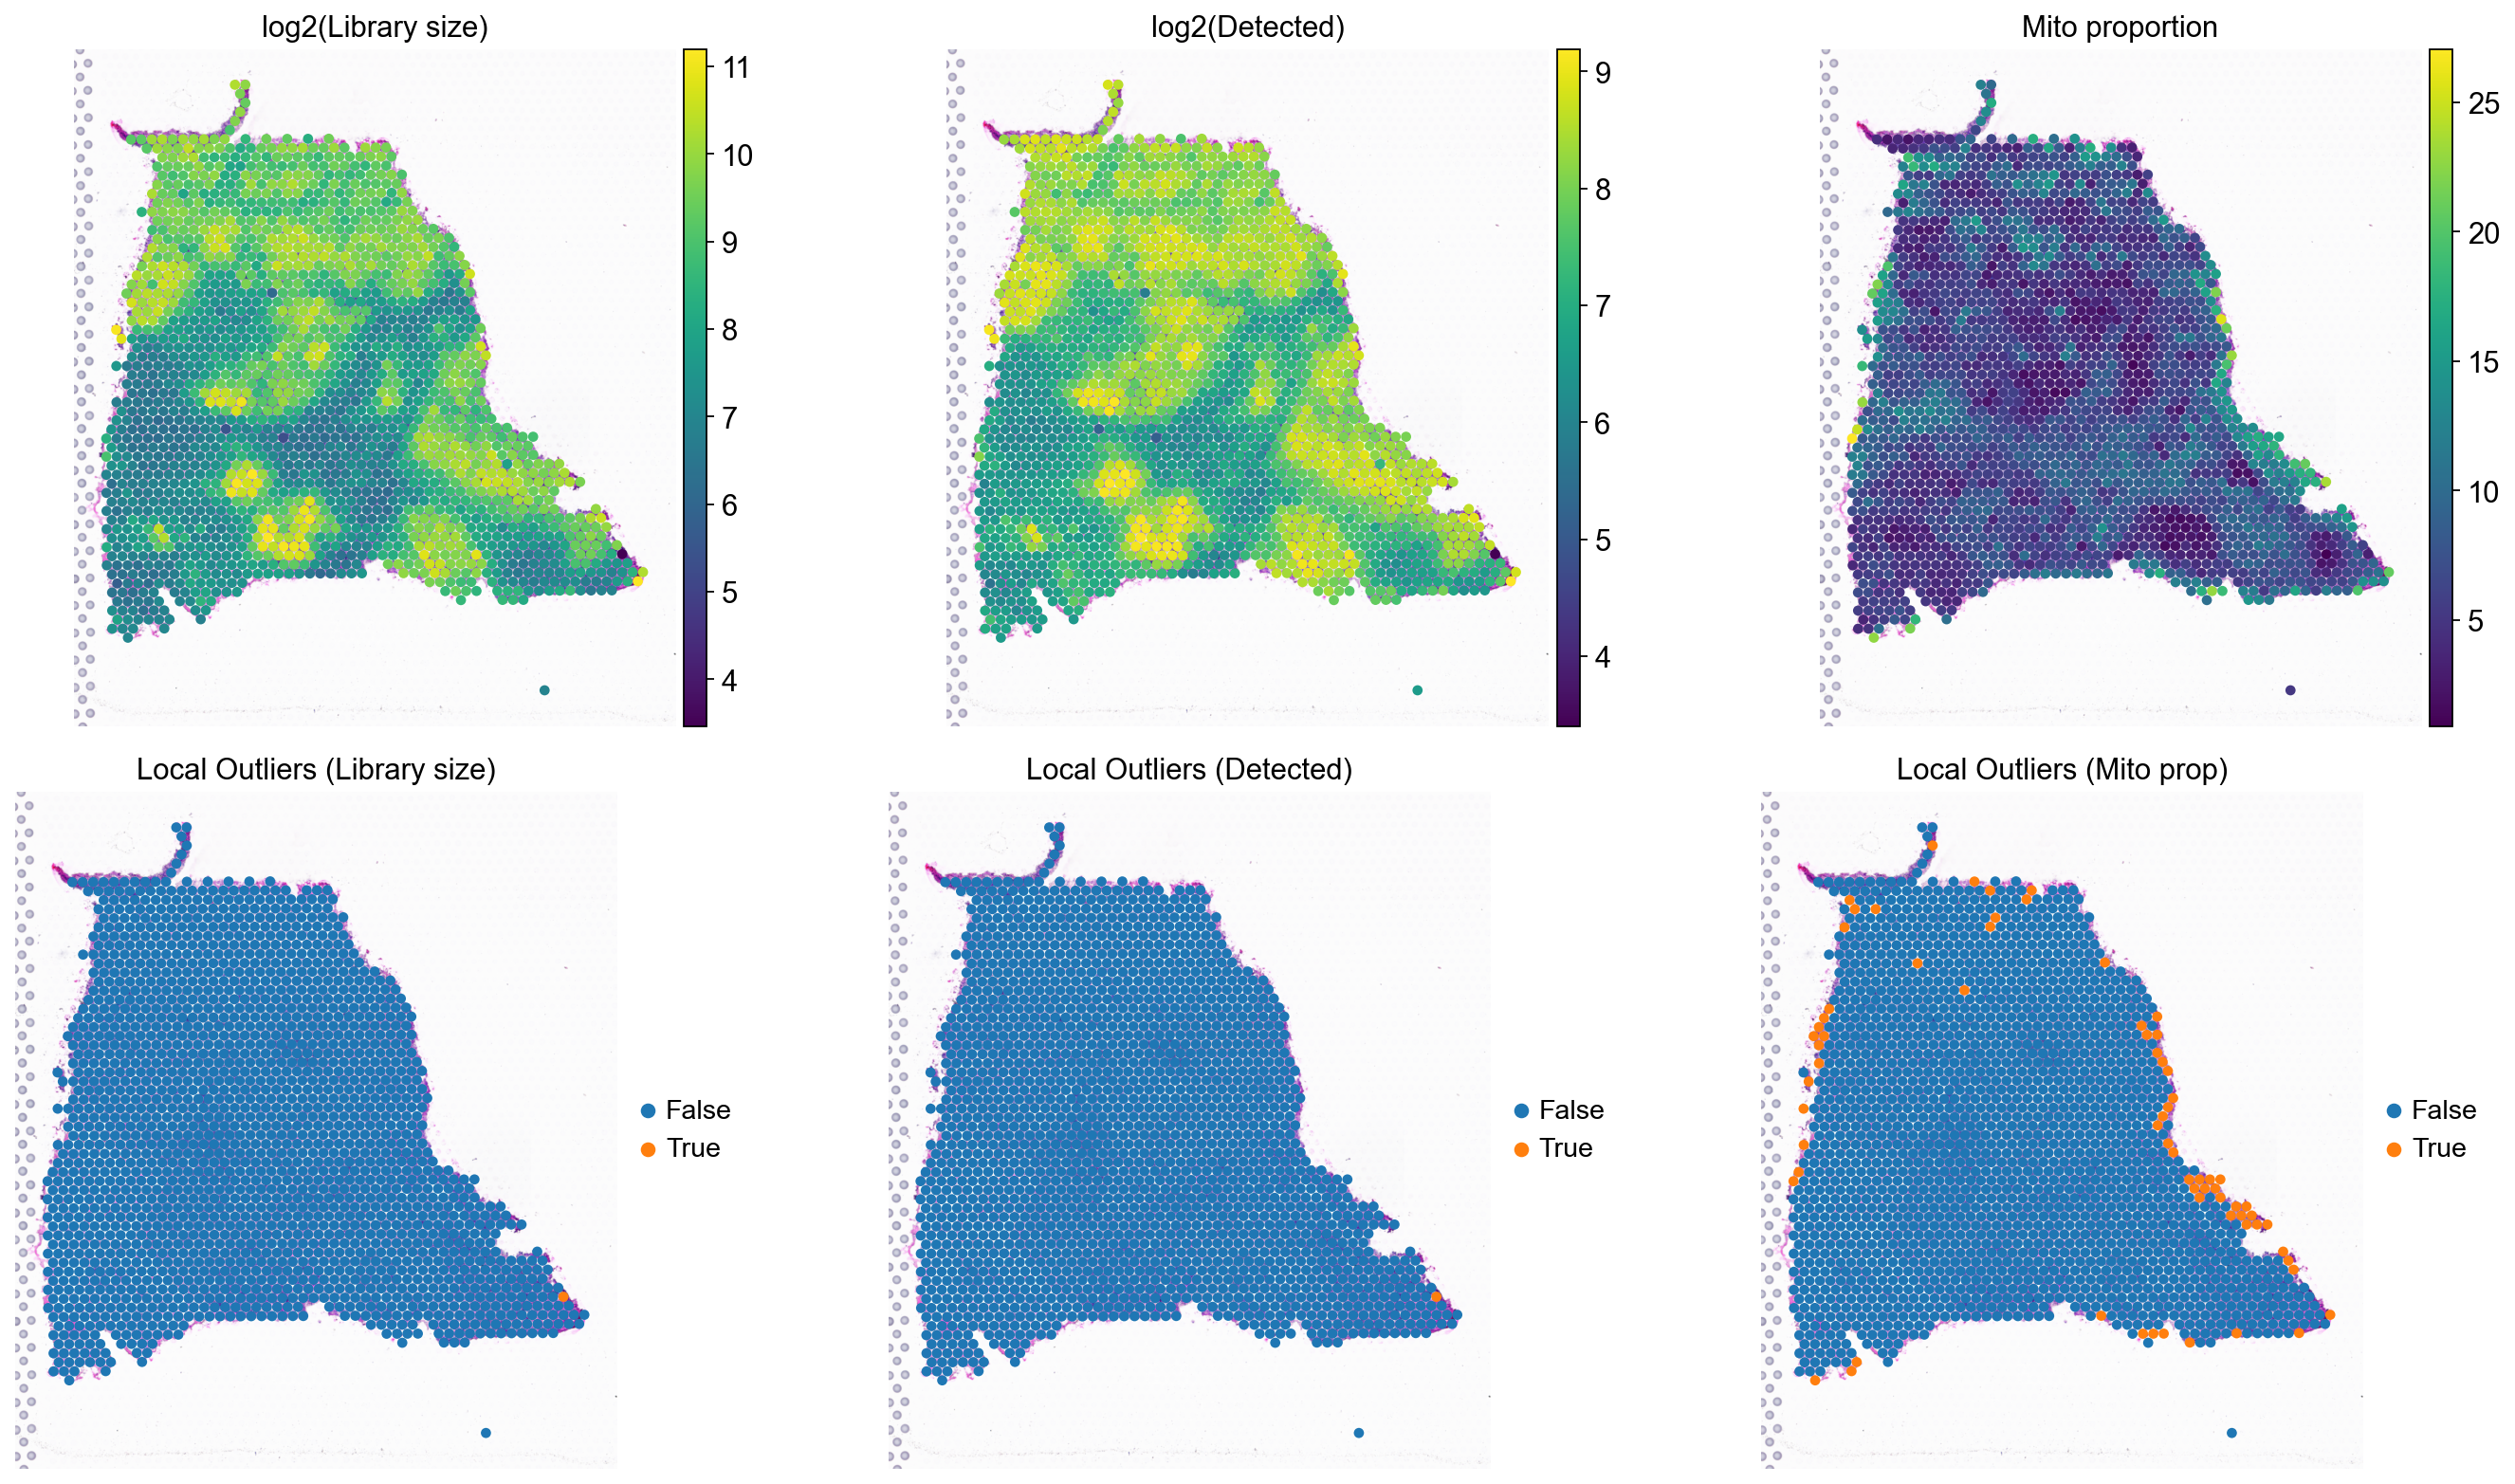

In [114]:
# Create 2 rows × 3 columns of subplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))

# Flatten the axes array to index it linearly
axes = axes.flatten()

sc.pl.spatial(
    adata,
    color="log1p_total_counts",
    library_id="GSM6592049_M2",
    cmap="viridis",  # or any colormap
    size=1.5,
    title="log2(Library size)",
    ax=axes[0],
    show=False
)

sc.pl.spatial(
    adata,
    color="sum_outliers",
    library_id="GSM6592049_M2",
    cmap="viridis",  # or any colormap
    size=1.5,
    title="Local Outliers (Library size)",
    ax=axes[3],
    show=False
)


sc.pl.spatial(
    adata,
    color="log1p_n_genes_by_counts",
    library_id="GSM6592049_M2",
    cmap="viridis",  # or any colormap
    size=1.5,
    title="log2(Detected)",
    ax=axes[1],
    show=False
)

sc.pl.spatial(
    adata,
    color="detected_outliers",
    library_id="GSM6592049_M2",
    cmap="viridis",  # or any colormap
    size=1.5,
    title="Local Outliers (Detected)",
    ax=axes[4],
    show=False
)

sc.pl.spatial(
    adata,
    color="pct_counts_mt",
    library_id="GSM6592049_M2",
    cmap="viridis",  # or any colormap
    size=1.5,
    title="Mito proportion",
    ax=axes[2],
    show=False
)

sc.pl.spatial(
    adata,
    color="mt_pct_outliers",
    library_id="GSM6592049_M2",
    cmap="viridis",  # or any colormap
    size=1.5,
    title="Local Outliers (Mito prop)",
    ax=axes[5],
    show=False
)

plt.tight_layout()
plt.show()

## 9.5 Remove low-quality spots

In [115]:
# combine global outliers
adata.obs["global_outliers"] = (adata.obs["qc_lib_size"].values) | (adata.obs["qc_detected"].values) | (adata.obs["qc_mito_prop"].values)
adata.obs.global_outliers.value_counts()

global_outliers
False    1822
True       26
Name: count, dtype: int64

In [116]:
# combine local outliers
adata.obs["local_outliers"] = (adata.obs["sum_outliers"].values) | (adata.obs["detected_outliers"].values) | (adata.obs["mt_pct_outliers"].values)
adata.obs.local_outliers.value_counts()

local_outliers
False    1777
True       71
Name: count, dtype: int64

C:\Users\rebec\AppData\Local\Temp\ipykernel_8292\4050174888.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
C:\Users\rebec\AppData\Local\Temp\ipykernel_8292\4050174888.py:15: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


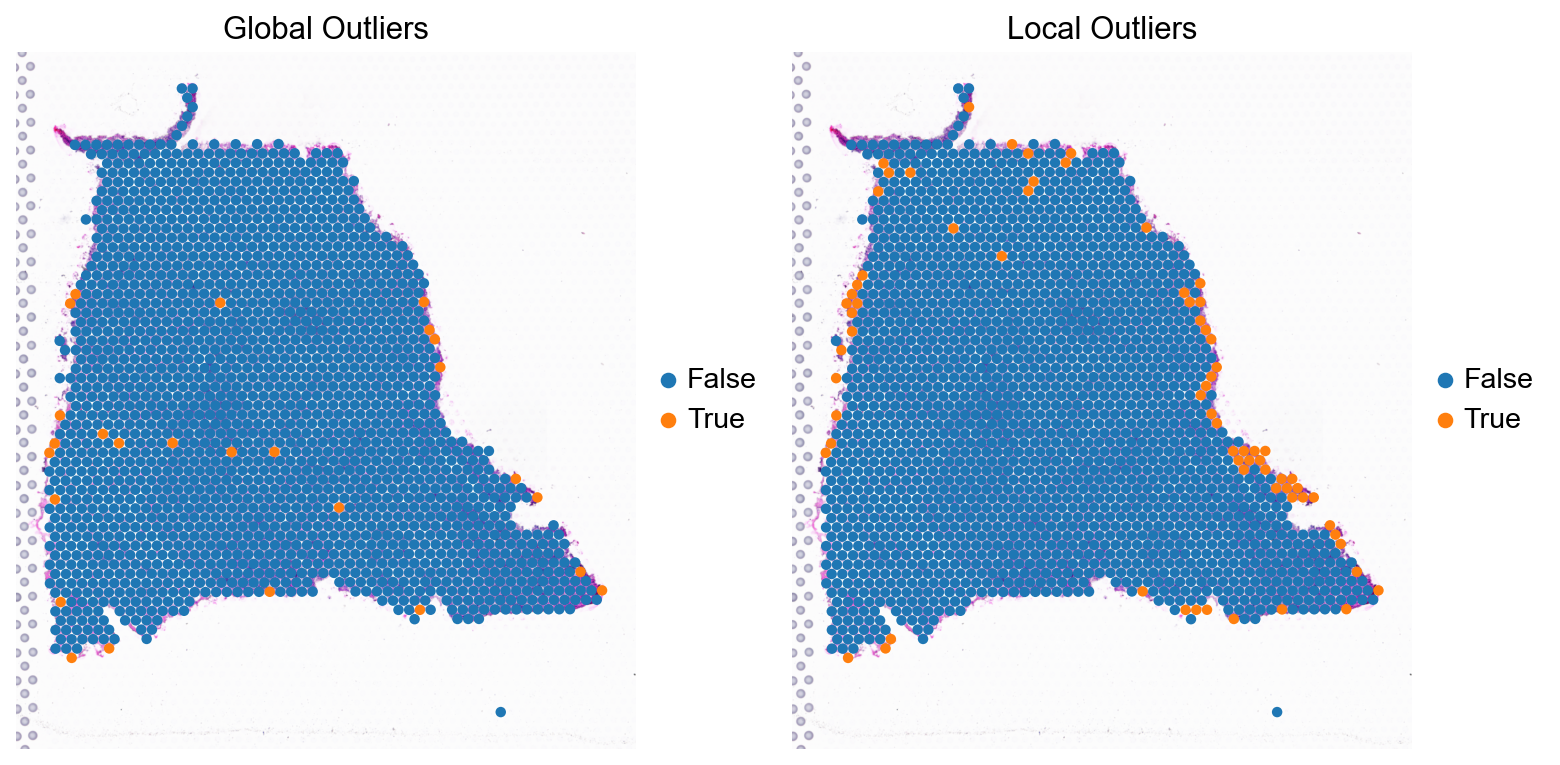

In [118]:
# Create a row of 3 subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # 1 row, 2 columns

sc.pl.spatial(
    adata,
    color="global_outliers",
    library_id="GSM6592049_M2",
    cmap="viridis",  # or any colormap
    size=1.5,
    title="Global Outliers",
    ax=axes[0],
    show=False
)

sc.pl.spatial(
    adata,
    color="local_outliers",
    library_id="GSM6592049_M2",
    cmap="viridis",  # or any colormap
    size=1.5,
    title="Local Outliers",
    ax=axes[1],
    show=False
)

plt.tight_layout()
plt.show()

In [119]:
# combine local and global outliers and store in 'discard' column
adata.obs["discard"] = (adata.obs["global_outliers"].values) | (adata.obs["local_outliers"].values)

# remove combined set of low-quality spots
adata = adata[adata.obs["discard"] == True, :]

# remove features with all 0 counts
sc.pp.filter_genes(adata, min_counts=1)

adata

c:\Users\rebec\miniforge3\envs\mapra\lib\site-packages\scanpy\preprocessing\_simple.py:291: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_counts"] = number


AnnData object with n_obs × n_vars = 81 × 16485
    obs: 'in_tissue', 'array_row', 'array_col', 'suspension_type', 'assay_ontology_term_id', 'Sample_ID', 'organism_ontology_term_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_type', 'tissue_ontology_term_id', 'pathologist_annotation', 'B-cells', 'CAFs', 'Cancer Epithelial', 'Endothelial', 'Myeloid', 'Normal Epithelial', 'PVL', 'T-cells', 'stereoscope_annotation', 'cell_type_ontology_term_id', 'is_primary_data', 'treatment', 'donor_id', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'qc_lib_